<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Cavity_QED_in_Phase_Space_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [7]:
!uv pip install --system -q qutip "k3d==3.0.1" matplotlib ipywidgets

QuTiP version: 5.3.1
K3D version: 3.1.0



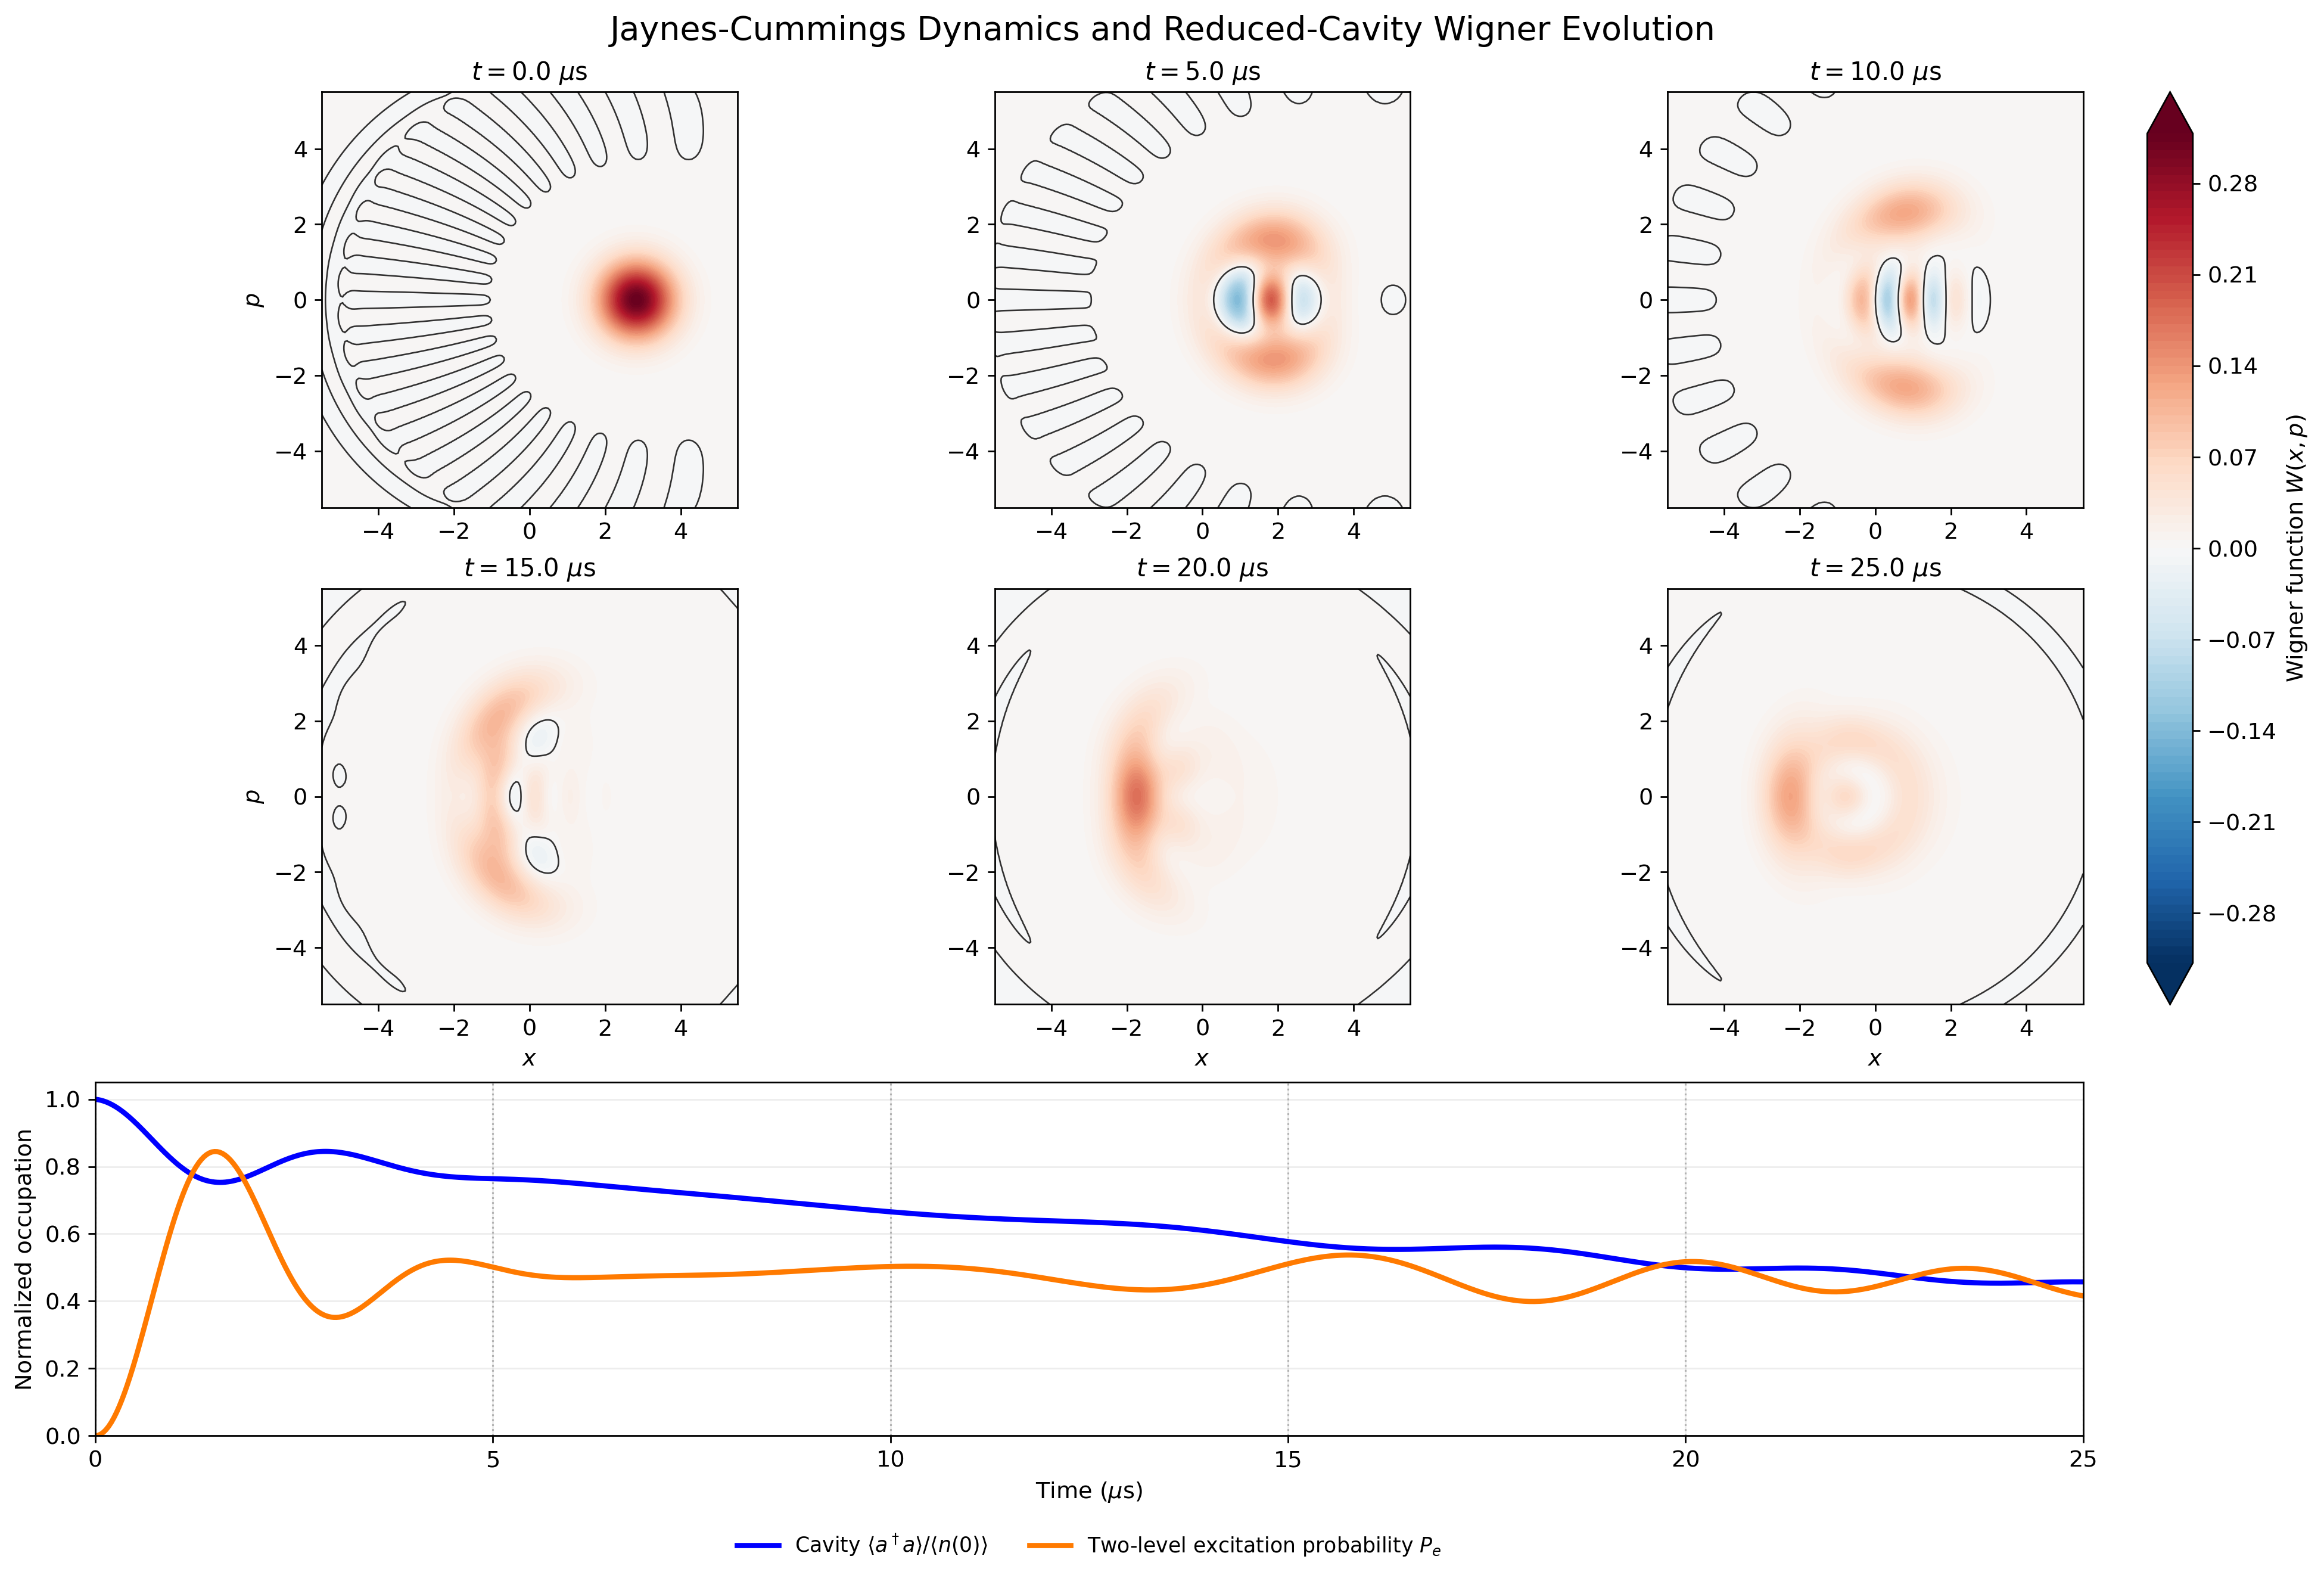

Calculating 64 K3D Wigner animation frames...
  Frame  1/64
  Frame  8/64
  Frame 16/64
  Frame 24/64
  Frame 32/64
  Frame 40/64
  Frame 48/64
  Frame 56/64
  Frame 64/64

K3D time range: 0.000 to 25.000 microseconds
K3D keyframes: 64
K3D rendering rate: 24.0 FPS
K3D time speed: 2.500 microseconds per second
Approximate loop duration: 10.00 seconds


Output()

In [8]:
"""Visualize cavity-QED dynamics in phase space with QuTiP, Matplotlib, and K3D.

This script simulates a dissipative Jaynes-Cummings system
consisting of a quantized cavity mode coupled to a two-level system. QuTiP
solves the Lindblad master equation and calculates reduced-cavity Wigner
functions. Matplotlib displays time-resolved two-dimensional Wigner
snapshots together with the cavity photon population and two-level-system
excitation probability.

K3D renders the reduced-cavity Wigner function as an interactive
three-dimensional phase-space surface.
"""

# - Imports
import k3d
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import qutip
from matplotlib.colors import TwoSlopeNorm
from qutip import (
    basis,
    coherent,
    destroy,
    mesolve,
    qeye,
    sigmam,
    sigmaz,
    tensor,
    wigner,
)


# - Control knobs

# Hilbert-space configuration.
CAVITY_DIM = 24
COHERENT_ALPHA = 2.0 + 0.0j

# Hamiltonian parameters in MHz.
COUPLING_MHZ = 0.08
CAVITY_DETUNING_MHZ = 0.0
ATOM_DETUNING_MHZ = 0.0

# Dissipation rates quoted as rate / 2π in MHz.
CAVITY_DECAY_MHZ = 0.004
ATOM_RELAXATION_MHZ = 0.002
ATOM_DEPHASING_MHZ = 0.001

# Time domain in microseconds.
TIME_MAX_US = 25.0
TIME_POINTS = 751

SNAPSHOT_TIMES_US = (
    0.0,
    5.0,
    10.0,
    15.0,
    20.0,
    25.0,
)

# Wigner phase-space configuration.
PHASE_SPACE_LIMIT = 5.5
PHASE_SPACE_POINTS = 181
WIGNER_METHOD = "clenshaw"
CONTOUR_LEVELS = 101

# K3D animation configuration.
K3D_ANIMATION_FRAMES = 64
K3D_FPS = 24.0
K3D_LOOP_DURATION_S = 10.0
K3D_TIME_INTERPOLATION = True
K3D_NORMALIZE_HEIGHT = True

# K3D rendering configuration.
K3D_HEIGHT = 650
K3D_ANTIALIAS = 3
K3D_SCREENSHOT_SCALE = 2.0
K3D_ROUGHNESS = 0.23
K3D_METALNESS = 0.0
K3D_COMPRESSION_LEVEL = 5

# Matplotlib configuration.
FIGURE_DPI = 250
PURE_BLUE = "#0000FF"
CONTRAST_ORANGE = "#FF7A00"
WIGNER_CMAP = "RdBu_r"

mpl.rcParams.update(
    {
        "figure.dpi": FIGURE_DPI,
        "savefig.dpi": FIGURE_DPI,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "lines.linewidth": 2.2,
    }
)


# - Quantum dynamics

def simulate_system():
    """Simulate a dissipative Jaynes-Cummings cavity-QED system."""
    cavity_identity = qeye(CAVITY_DIM)
    atom_identity = qeye(2)

    # Composite Hilbert-space operators.
    cavity_destroy = tensor(
        destroy(CAVITY_DIM),
        atom_identity,
    )
    atom_lower = tensor(
        cavity_identity,
        sigmam(),
    )
    atom_z = tensor(
        cavity_identity,
        sigmaz(),
    )

    cavity_number = cavity_destroy.dag() * cavity_destroy
    atom_excited = atom_lower.dag() * atom_lower

    # MHz × 2π gives angular frequency in rad / microsecond.
    coupling = 2.0 * np.pi * COUPLING_MHZ
    cavity_detuning = 2.0 * np.pi * CAVITY_DETUNING_MHZ
    atom_detuning = 2.0 * np.pi * ATOM_DETUNING_MHZ

    # Jaynes-Cummings Hamiltonian in the rotating frame.
    hamiltonian = (
        cavity_detuning * cavity_number
        + 0.5 * atom_detuning * atom_z
        + coupling
        * (
            cavity_destroy.dag() * atom_lower
            + cavity_destroy * atom_lower.dag()
        )
    )

    cavity_decay = 2.0 * np.pi * CAVITY_DECAY_MHZ
    atom_relaxation = 2.0 * np.pi * ATOM_RELAXATION_MHZ
    atom_dephasing = 2.0 * np.pi * ATOM_DEPHASING_MHZ

    collapse_operators = []

    if cavity_decay > 0.0:
        collapse_operators.append(
            np.sqrt(cavity_decay) * cavity_destroy
        )

    if atom_relaxation > 0.0:
        collapse_operators.append(
            np.sqrt(atom_relaxation) * atom_lower
        )

    if atom_dephasing > 0.0:
        collapse_operators.append(
            np.sqrt(atom_dephasing / 2.0) * atom_z
        )

    # Prepare a coherent cavity state and the lower sigma_z state.
    cavity_state = coherent(
        CAVITY_DIM,
        COHERENT_ALPHA,
    )
    atom_ground = basis(2, 1)

    initial_state = tensor(
        cavity_state,
        atom_ground,
    )

    time_list = np.linspace(
        0.0,
        TIME_MAX_US,
        TIME_POINTS,
        dtype=float,
    )

    result = mesolve(
        hamiltonian,
        initial_state,
        time_list,
        c_ops=collapse_operators,
        e_ops=[
            cavity_number,
            atom_excited,
        ],
        options={
            "store_states": True,
            "progress_bar": "",
        },
    )

    mean_photon_number = np.asarray(
        result.expect[0],
        dtype=float,
    )

    atom_excited_probability = np.asarray(
        result.expect[1],
        dtype=float,
    )

    return (
        result,
        time_list,
        mean_photon_number,
        atom_excited_probability,
    )


def calculate_wigner_snapshots(result, time_list):
    """Calculate reduced-cavity Wigner functions at selected times."""
    phase_axis = np.linspace(
        -PHASE_SPACE_LIMIT,
        PHASE_SPACE_LIMIT,
        PHASE_SPACE_POINTS,
        dtype=float,
    )

    snapshot_indices = [
        int(
            np.argmin(
                np.abs(time_list - target_time)
            )
        )
        for target_time in SNAPSHOT_TIMES_US
    ]

    wigner_snapshots = []

    for state_index in snapshot_indices:
        # Trace out the two-level subsystem.
        cavity_density = result.states[state_index].ptrace(0)

        wigner_values = wigner(
            cavity_density,
            phase_axis,
            phase_axis,
            method=WIGNER_METHOD,
        )

        wigner_snapshots.append(
            np.asarray(
                wigner_values,
                dtype=float,
            )
        )

    return (
        phase_axis,
        snapshot_indices,
        wigner_snapshots,
    )


def build_k3d_wigner_animation(
    result,
    time_list,
    phase_axis,
):
    """Build an automatically looping K3D Wigner-surface animation."""
    frame_indices = np.unique(
        np.linspace(
            0,
            len(time_list) - 1,
            K3D_ANIMATION_FRAMES,
            dtype=int,
        )
    )

    frame_times = time_list[frame_indices]

    print(
        "Calculating "
        f"{len(frame_indices)} K3D Wigner animation frames..."
    )

    wigner_frames = []

    for frame_number, state_index in enumerate(
        frame_indices,
        start=1,
    ):
        cavity_density = result.states[state_index].ptrace(0)

        wigner_values = wigner(
            cavity_density,
            phase_axis,
            phase_axis,
            method=WIGNER_METHOD,
        )

        wigner_frame = np.ascontiguousarray(
            wigner_values,
            dtype=np.float32,
        )
        wigner_frames.append(wigner_frame)

        if (
            frame_number == 1
            or frame_number == len(frame_indices)
            or frame_number % 8 == 0
        ):
            print(
                f"  Frame {frame_number:>2}/"
                f"{len(frame_indices)}"
            )

    # A single global scale prevents the meaning of color from
    # changing between animation frames.
    global_wigner_limit = max(
        float(np.max(np.abs(frame)))
        for frame in wigner_frames
    )

    global_wigner_limit = max(
        global_wigner_limit,
        float(np.finfo(np.float32).eps),
    )

    height_series = {}
    attribute_series = {}

    for frame_time, wigner_frame in zip(
        frame_times,
        wigner_frames,
    ):
        time_key = f"{frame_time:.9f}"

        if K3D_NORMALIZE_HEIGHT:
            height_frame = (
                wigner_frame / global_wigner_limit
            )
        else:
            height_frame = wigner_frame

        height_series[time_key] = np.ascontiguousarray(
            height_frame,
            dtype=np.float32,
        )

        attribute_series[time_key] = np.ascontiguousarray(
            wigner_frame,
            dtype=np.float32,
        )

    first_key = f"{frame_times[0]:.9f}"

    # Wigner negativity appears in pure blue, zero appears white,
    # and positive quasiprobability appears red.
    diverging_color_map = [
        [0.0, 0.0, 0.0, 1.0],
        [0.5, 1.0, 1.0, 1.0],
        [1.0, 1.0, 0.0, 0.0],
    ]

    if K3D_NORMALIZE_HEIGHT:
        z_axis_label = "W(x,p) / max|W|"
    else:
        z_axis_label = "W(x,p)"

    surface = k3d.surface(
        height_series[first_key],
        xmin=float(phase_axis[0]),
        xmax=float(phase_axis[-1]),
        ymin=float(phase_axis[0]),
        ymax=float(phase_axis[-1]),
        attribute=attribute_series[first_key],
        color_map=diverging_color_map,
        color_range=[
            -global_wigner_limit,
            global_wigner_limit,
        ],
        wireframe=False,
        flat_shading=False,
        roughness=K3D_ROUGHNESS,
        metalness=K3D_METALNESS,
        compression_level=K3D_COMPRESSION_LEVEL,
        name="Reduced-cavity Wigner function",
    )

    # K3D recognizes dictionaries with numerical string keys as
    # frontend time series.
    surface.heights = height_series
    surface.attribute = attribute_series

    k3d_plot = k3d.plot(
        height=K3D_HEIGHT,
        antialias=K3D_ANTIALIAS,
        background_color=0x000000,
        grid_visible=False,
        label_color=0xFFFFFF,
        axes=[
            "x quadrature",
            "p quadrature",
            z_axis_label,
        ],
        camera_mode="orbit",
        screenshot_scale=K3D_SCREENSHOT_SCALE,
        menu_visibility=True,
        renderer="simple",
    )

    k3d_plot += surface

    # K3D evaluates time_speed in time-series units per real second.
    simulated_duration = float(
        frame_times[-1] - frame_times[0]
    )

    requested_time_speed = (
        simulated_duration / K3D_LOOP_DURATION_S
    )

    # The interactive K3D panel exposes time speeds from 0.1 to 5.0.
    animation_time_speed = float(
        np.clip(
            requested_time_speed,
            0.1,
            5.0,
        )
    )

    k3d_plot.fps = float(K3D_FPS)
    k3d_plot.time_speed = animation_time_speed
    k3d_plot.time_interpolation = K3D_TIME_INTERPOLATION
    k3d_plot.time = float(frame_times[0])

    return (
        k3d_plot,
        surface,
        frame_times,
        global_wigner_limit,
        animation_time_speed,
    )


# - Run QuTiP simulation

print(f"QuTiP version: {qutip.__version__}")
print(f"K3D version: {k3d.__version__}")
print()

output, tlist, n_c, n_a = simulate_system()

xvec, t_idx, wigner_data = calculate_wigner_snapshots(
    output,
    tlist,
)


# - Shared Wigner normalization

wigner_limit = max(
    float(np.max(np.abs(values)))
    for values in wigner_data
)

wigner_limit = max(
    wigner_limit,
    np.finfo(float).eps,
)

wigner_norm = TwoSlopeNorm(
    vmin=-wigner_limit,
    vcenter=0.0,
    vmax=wigner_limit,
)

wigner_levels = np.linspace(
    -wigner_limit,
    wigner_limit,
    CONTOUR_LEVELS,
)


# - Matplotlib Wigner snapshots

fig = plt.figure(
    figsize=(15.5, 10.5),
    constrained_layout=True,
)

grid = fig.add_gridspec(
    3,
    3,
    height_ratios=(
        1.0,
        1.0,
        0.85,
    ),
)

wigner_axes = []
contour = None

for panel_index, (
    state_index,
    wigner_values,
) in enumerate(
    zip(
        t_idx,
        wigner_data,
    )
):
    row = panel_index // 3
    column = panel_index % 3

    ax = fig.add_subplot(
        grid[row, column]
    )
    wigner_axes.append(ax)

    contour = ax.contourf(
        xvec,
        xvec,
        wigner_values,
        levels=wigner_levels,
        cmap=WIGNER_CMAP,
        norm=wigner_norm,
        extend="both",
    )

    # Mark the zero-Wigner boundary if both signs are present.
    if (
        np.min(wigner_values) < 0.0
        < np.max(wigner_values)
    ):
        ax.contour(
            xvec,
            xvec,
            wigner_values,
            levels=[0.0],
            colors="black",
            linewidths=0.75,
            alpha=0.8,
        )

    ax.set_title(
        rf"$t={tlist[state_index]:.1f}"
        rf"\ \mu\mathrm{{s}}$"
    )

    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    if row == 1:
        ax.set_xlabel(r"$x$")

    if column == 0:
        ax.set_ylabel(r"$p$")


# One Wigner scale makes all six snapshots directly comparable.
colorbar = fig.colorbar(
    contour,
    ax=wigner_axes,
    fraction=0.035,
    pad=0.025,
)

colorbar.set_label(
    r"Wigner function $W(x,p)$"
)


# - One-dimensional dynamics

ax_dynamics = fig.add_subplot(
    grid[2, :]
)

initial_photon_number = max(
    float(n_c[0]),
    np.finfo(float).eps,
)

normalized_cavity_population = (
    n_c / initial_photon_number
)

ax_dynamics.plot(
    tlist,
    normalized_cavity_population,
    color=PURE_BLUE,
    linewidth=2.5,
    label=(
        r"Cavity "
        r"$\langle a^\dagger a\rangle/"
        r"\langle n(0)\rangle$"
    ),
)

ax_dynamics.plot(
    tlist,
    n_a,
    color=CONTRAST_ORANGE,
    linewidth=2.5,
    label=(
        r"Two-level excitation probability $P_e$"
    ),
)

# Vertical guides identify the Wigner snapshot times.
for snapshot_time in SNAPSHOT_TIMES_US:
    ax_dynamics.axvline(
        snapshot_time,
        color="0.70",
        linestyle=":",
        linewidth=0.9,
        zorder=0,
    )

ax_dynamics.set_xlabel(
    r"Time $(\mu\mathrm{s})$"
)

ax_dynamics.set_ylabel(
    "Normalized occupation"
)

ax_dynamics.set_xlim(
    tlist[0],
    tlist[-1],
)

ax_dynamics.set_ylim(
    0.0,
    1.05
    * max(
        1.0,
        float(
            np.max(
                normalized_cavity_population
            )
        ),
        float(np.max(n_a)),
    ),
)

ax_dynamics.grid(
    alpha=0.22,
)

ax_dynamics.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=2,
    frameon=False,
)

fig.suptitle(
    "Jaynes-Cummings Dynamics and "
    "Reduced-Cavity Wigner Evolution",
    fontsize=16,
)

plt.show()


# - K3D Wigner animation

(
    k3d_plot,
    k3d_surface,
    k3d_frame_times,
    k3d_wigner_limit,
    k3d_time_speed,
) = build_k3d_wigner_animation(
    output,
    tlist,
    xvec,
)

print()
print(
    "K3D time range: "
    f"{k3d_frame_times[0]:.3f} to "
    f"{k3d_frame_times[-1]:.3f} microseconds"
)
print(
    f"K3D keyframes: {len(k3d_frame_times)}"
)
print(
    f"K3D rendering rate: {K3D_FPS:.1f} FPS"
)
print(
    f"K3D time speed: {k3d_time_speed:.3f} "
    "microseconds per second"
)

actual_loop_duration = (
    float(
        k3d_frame_times[-1]
        - k3d_frame_times[0]
    )
    / k3d_time_speed
)

print(
    f"Approximate loop duration: "
    f"{actual_loop_duration:.2f} seconds"
)

# Display the widget before beginning frontend playback.
k3d_plot.display()

# Autoplay wraps continuously at the end of the time-series range.
k3d_plot.start_auto_play()

## Example Results from the K3D Viewer

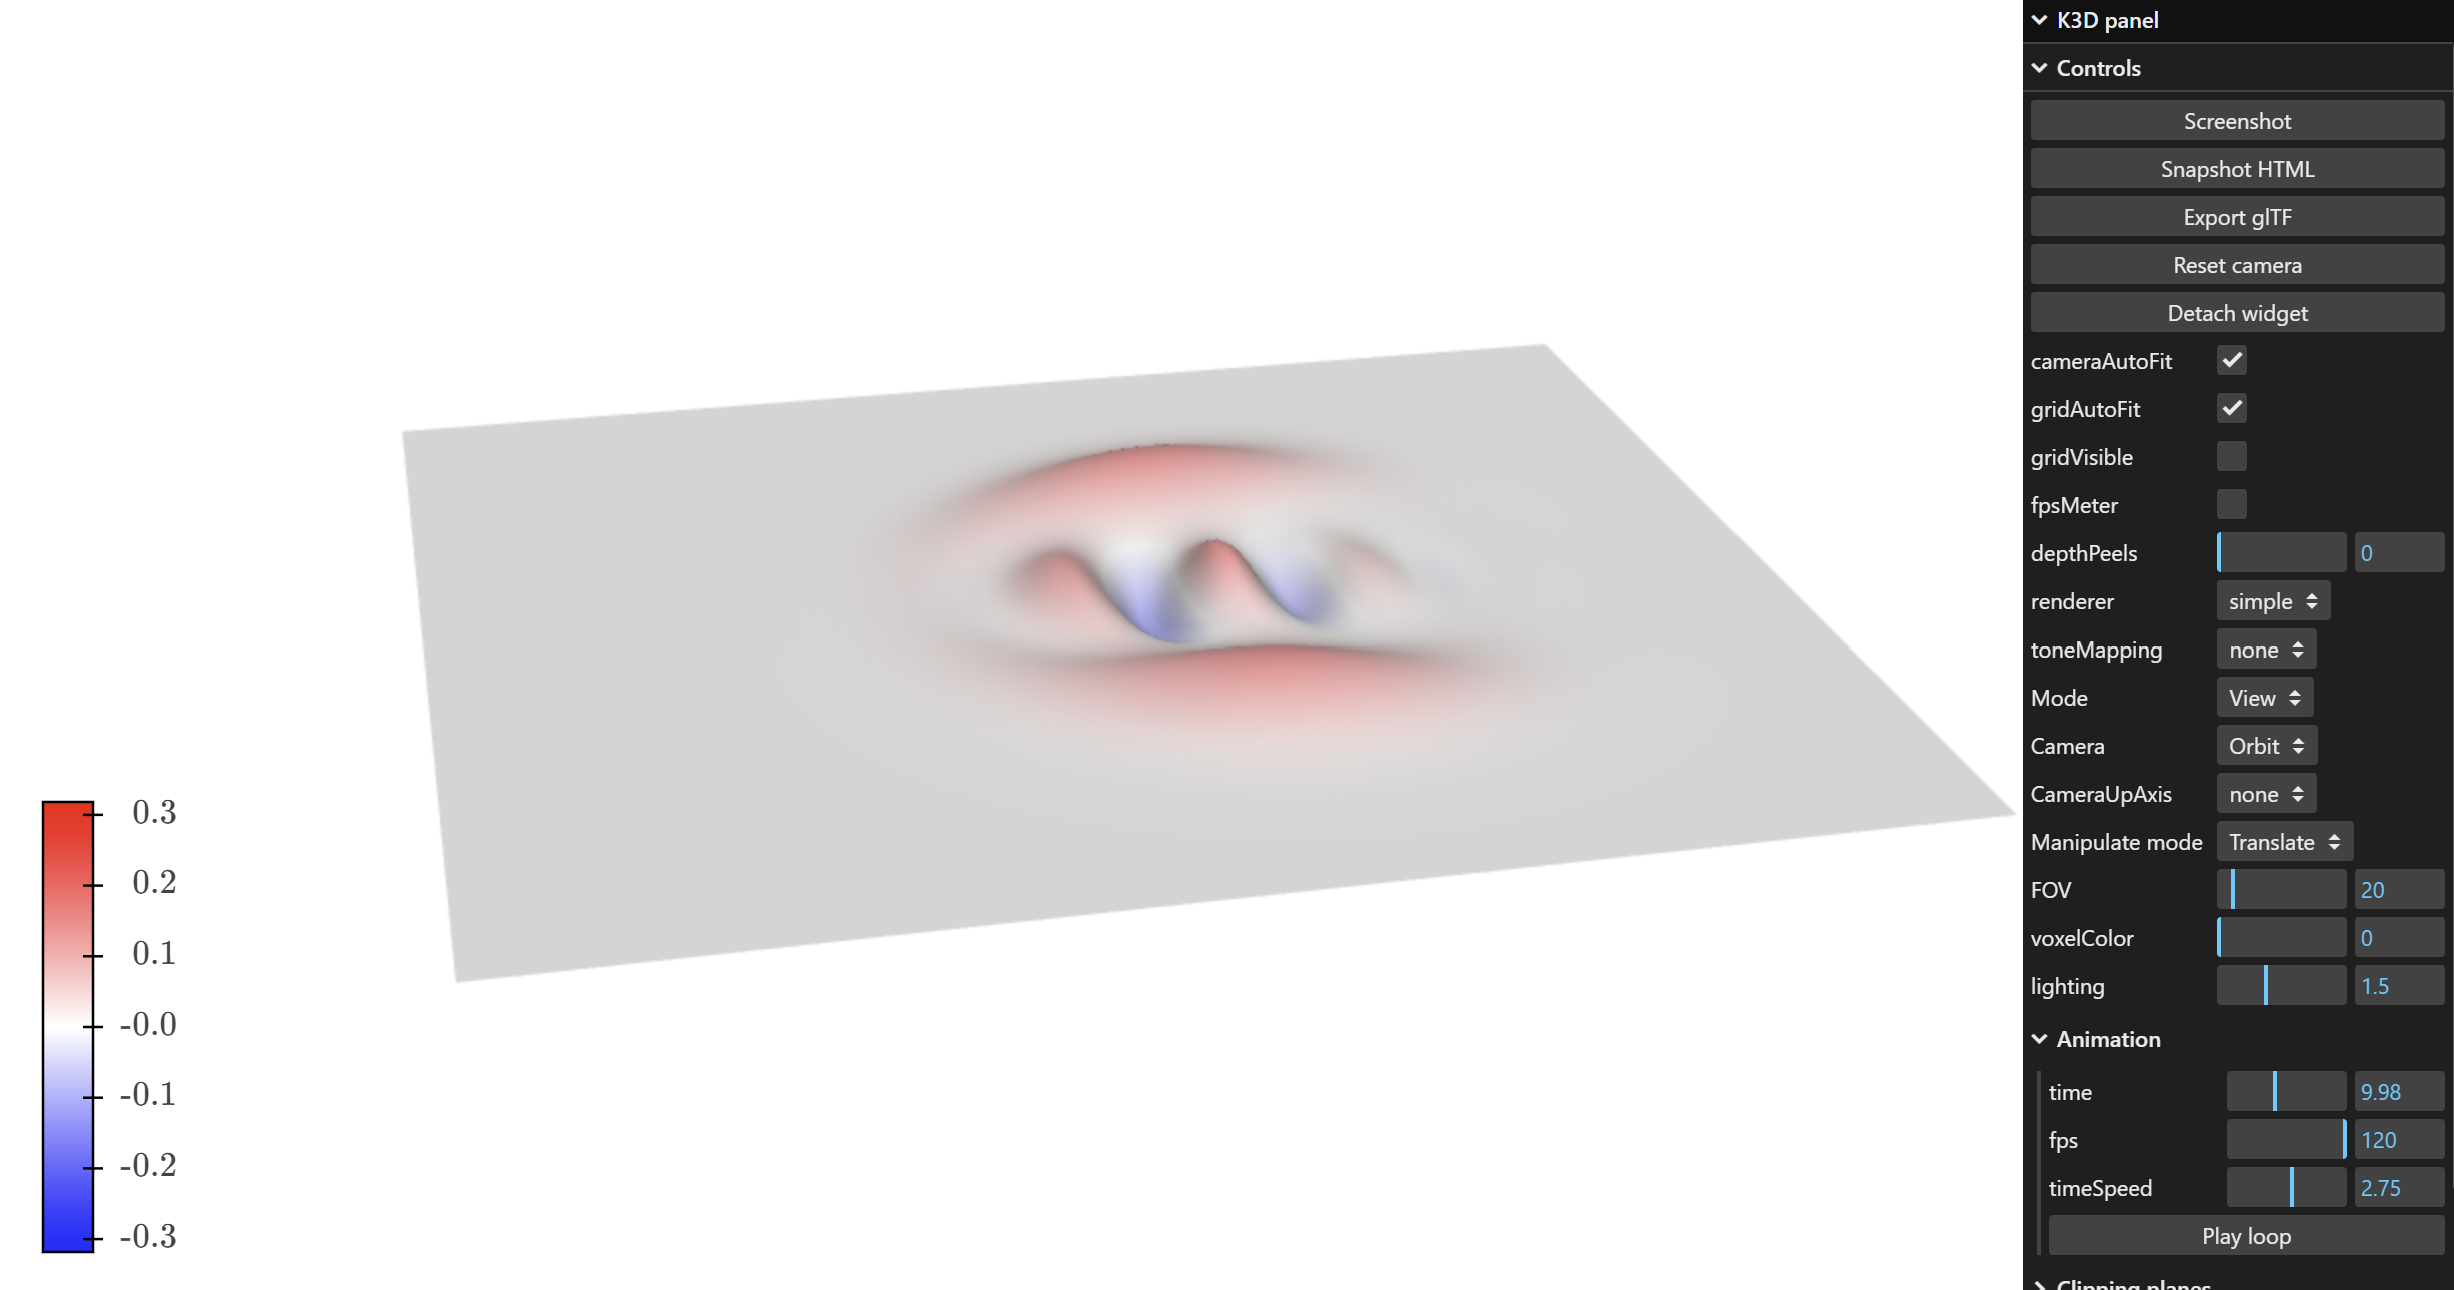